In [100]:
import warnings
import time
from dataclasses import dataclass
from typing import List, Optional
from collections import Counter, deque

import pandas as pd
import numpy as np
from sklearn.preprocessing import (
    MinMaxScaler,
)
from sklearn.linear_model import (
    Lasso,
    Ridge,
    ElasticNet
)
from sklearn.metrics import (
    silhouette_score,
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
plt.style.use('seaborn-v0_8')

| Item          | Version  |
|-------------------|---------|
| Kernel            | Python 3.12.0 |
| sklearn           | 1.7.1   |
| pandas            | 2.3.2   |
| seaborn           | 0.13.2  |
| matplotlib        | 3.10.6  |

In [101]:
notebook_time = time.time()

#### 1. Answer the questions from the introduction

##### 1.1 Propose a new method to initialize cluster centroids for K-means. List the advantages and disadvantages of Forgy, Random Partition, and your own initializations.

| Feature | Forgy | Random Partition | Variance-Driven Spread |
| :--- | :--- | :--- | :--- |
| **Definition** | Randomly selects `k` distinct data points from the dataset to serve as the initial centroids. | Randomly assigns each data point to one of the `k` clusters, then calculates the centroid (mean) of these random groups to get the initial centroids. | Selects initial centroids by identifying the axis of maximum variance, partitioning this axis into `k` segments, and picking a representative point from each segment. |
| **Advantages** | 1. **Simple** and intuitive to understand. <br> 2. **Fast** execution, as it's just a random selection. <br> 3. Guarantees that initial centroids are actual data points. | 1. **Simple** to implement. <br> 2. Tends to produce initial centroids that are closer to the overall data mean, which can be more stable in some cases than outliers. <br> 3. Less prone to selecting outliers compared to Forgy. | 1. **Deterministic Spread:** Ensures centroids are well-distributed along the principal axis, leading to better separation from the start. <br> 2. **Reduces Empty Cluster Risk:** By partitioning the space, it is less likely to place all centroids in one dense region. <br> 3. **Data-Aware:** It uses the statistical properties (variance) of the data without being as computationally heavy as K-means++. |
| **Disadvantages** | 1. **High Variance:** Can produce poor results if random picks are clumped in the same region of space. <br> 2. **Sensitive to Outliers:** If a randomly picked point is an outlier, the initial centroid can be misleading. | 1. **Centroids are "Fictional":** Initial centroids are means of random noise, not actual data points, which might be less representative initially. <br> 2. **Clusters are Evenly Distributed:** It forces the initial clusters to be roughly the same size, which can be a bad starting point if the true clusters have vastly different sizes. | 1. **Slightly More Complex:** Requires projecting data and finding quantiles/medians, making it more computationally expensive than the other two simple methods (though still O(n)). <br> 2. **Axis-Biased:** Assumes the principal axis of variance is the best direction to separate clusters. This might fail for clusters that are not aligned with the global axis of maximum variance (e.g., concentric circles). |

<!-- | Feature | Forgy | Random Partition | Variance-Driven Spread |
| :--- | :--- | :--- | :--- |
| **Определение** | Случайным образом выбирает `k` различных точек данных из набора данных, которые служат в качестве начальных центроидов. | Случайным образом присваивает каждой точке данных один из `k` кластеров, затем вычисляет центроид (среднее значение) этих случайных групп, чтобы получить начальные центроиды. | Начальные центроиды выбираются путем определения оси максимальной дисперсии, разбиения этой оси на `k` сегментов и выбора репрезентативной точки из каждого сегмента. |
| **Преимущества** | 1. **Простота** и интуитивно понятен. <br> 2. **Быстрое** выполнение, поскольку это просто случайный выбор. <br> 3. Гарантирует, что начальные центроиды являются фактическими точками данных. | 1. **Простота** в реализации. <br> 2. Как правило, генерирует начальные центроиды, которые ближе к общему среднему значению данных, что в некоторых случаях может быть более стабильным, чем выбросы. <br> 3. Менее склонен к выбору выбросов по сравнению с алгоритмом Forgy. | 1. **Детерминированное распределение:** Обеспечивает равномерное распределение центроидов вдоль главной оси, что приводит к лучшему разделению с самого начала. <br> 2. **Снижает риск образования пустых кластеров:** Разделяя пространство, алгоритм с меньшей вероятностью разместит все центроиды в одной плотной области. <br> 3. **Учитывает данные:** Использует статистические свойства (дисперсию) данных, не будучи таким ресурсоемким в вычислительных задачах, как K-means++. |
| **Недостатки** | 1. **Высокая дисперсия:** Может давать плохие результаты, если случайные выборки сгруппированы в одной области пространства. <br> 2. **Чувствительность к выбросам:** Если случайно выбранная точка является выбросом, начальный центроид может ввести в заблуждение. | 1. **Центроиды являются «вымышленными»:** Начальные центроиды представляют собой средние значения случайного шума, а не фактические точки данных, которые могут быть менее репрезентативными на начальном этапе. <br> 2. **Кластеры равномерно распределены:** Это заставляет начальные кластеры быть примерно одинакового размера, что может быть плохой отправной точкой, если истинные кластеры имеют значительно разные размеры. | 1. **Немного сложнее:** Требует проецирования данных и нахождения квантилей/медиан, что делает его более вычислительно затратным, чем два других простых метода (хотя все еще O(n)). <br> 2. **Смещение по оси:** Предполагает, что главная ось дисперсии является наилучшим направлением для разделения кластеров. Это может не сработать для кластеров, которые не выровнены с глобальной осью максимальной дисперсии (например, концентрические круги). | -->

##### 1.2 Describe how you can use clustering to speed up the KNN model. Hint: what is kd-tree?

How Kd-tree works: the training data is sorted into a binary tree by recursively splitting the space along different axes (dimensions) at the median. <br>
Using clustering to speed up the KNN model: <br>
1. Rejection of Brute-Force Search:
- Instead of calculating distances to all \( O n \) points (naive KNN), the tree structure enables efficient pruning of entire groups of points.

2. Implementation in Code:

- Building (`_build`): The space is recursively partitioned into "clusters" (nodes). The key point is sorting by the median of the current axis (`axis`). This guarantees a balanced tree (depth ~ \( O log n \)).

- Search (`_query_radius`):
    1.  Traversal proceeds towards the target point (`diff <= 0` — go left/right).
    2.  Main Optimization: The second subtree is checked only under the condition `abs(diff) <= radius`.<br> 
    If the projection of the target point onto the current axis is farther from the splitting plane <br>
    than the search radius — all points on the other side of the plane are guaranteed to be outside the radius, and we do not check them.


<!-- Как работает Kd-дерево: обучающие данные сортируются в бинарное дерево путем рекурсивного разделения пространства по различным осям (измерениям) по медиане. <br>
Использование кластеризации для ускорения модели KNN: <br>
1. Отказ от поиска методом перебора:
- Вместо вычисления расстояний до всех \( O n \) точек (наивный KNN), древовидная структура позволяет эффективно отсеивать целые группы точек.

2. Реализация в коде:

- Построение (`_build`): Пространство рекурсивно разбивается на «кластеры» (узлы). Ключевым моментом является сортировка по медиане текущей оси (`axis`). Это гарантирует сбалансированное дерево (глубина ~ \( O log n \)).

- Поиск (`_query_radius`):
1. Обход продолжается к целевой точке (`diff <= 0` - двигаться влево/вправо).

2. Основная оптимизация: второе поддерево проверяется только при условии `abs(diff) <= radius`.<br>
Если проекция целевой точки на текущую ось находится дальше от плоскости разделения,<br>
чем радиус поиска, все точки по другую сторону плоскости гарантированно находятся за пределами радиуса, и мы их не проверяем. -->

#### 2. Introduction — make all the preprocessing staff from the previous lesson

In [102]:
# csv from materials not from kaggle, test from materials has interest lvl col
path: str = "data/train_test_renthop/{name}.csv"
train_df: pd.DataFrame = pd.read_csv(
    path.format(name="train"), parse_dates=[4], index_col=0,
)
train_df.name = "train_df"
test_df: pd.DataFrame = pd.read_csv(
    path.format(name="test"), parse_dates=[4], index_col=0,
)
test_df.name = "test_df"

In [103]:
for df in train_df, test_df:
    df["features"] = df["features"].apply(
        lambda x: 
            x.replace('"', '').replace('[', '').replace(']', '').replace("'", '').replace(' ', '')
    )

features_list: list = []

for num, row in train_df.iterrows():
    features_list += row['features'].split(',')

features_list = [x for x in features_list if x]
features_list = [x.replace(' ', '') for x in features_list ]
cnt = Counter(features_list).most_common(20)
features_list = [x[0] for x in cnt if x]

for x in features_list:
    train_df[x] = train_df['features'].str.contains(x, regex=False).astype(int)
    test_df[x] = test_df['features'].str.contains(x, regex=False).astype(int)

base_features_list: list = ["bathrooms", "bedrooms", "interest_level"]
features: list = features_list + base_features_list

#### 3. Implement the next methods:

##### 3.1 K-means algorithm.

In [104]:
@dataclass
class KMeans_():
    """
    The KMeans algorithm clusters data by trying to separate samples 
    in n groups of equal variance, minimizing a criterion 
    known as the inertia or within-cluster sum-of-squares

    Prepocess: Standard or MinMax scaler
    Stopping criteria in _kmeans_single method - centers shift
    Algo complexity (Fit): O(n_train_samples * n_features * n_clusters * n_iter)
    Algo complexity (Predict): O(n_test_samples * n_features * n_clusters)
    """
    n_clusters: int = 8
    n_init: int = 10
    max_iter: int = 300
    tol: float = 1e-4
    random_state: int = 42
    cluster_centers_ = None
    labels_ = None
    inertia_ = None
    n_iter_ = 0
    
    def _init_centroids(self, X, i):
        self.rng = np.random.RandomState(self.random_state + i)
        indices = self.rng.choice(self.n_samples, self.n_clusters, replace=False)
        return X[indices]
    
    def _pairwise_distances_argmin(self, X, centres):
        distances = np.zeros((X.shape[0], centres.shape[0]))
        for i in range(centres.shape[0]):
            distances[:, i] = np.sum((X - centres[i]) ** 2, axis=1)
        
        argmin = np.argmin(distances, axis=1)
        min_dist = distances[np.arange(X.shape[0]), argmin]
        return argmin, min_dist
    
    def _kmeans_single(self, X, init_centers):
        centers = init_centers.copy()
        
        for i in range(self.max_iter):
            labels, distances = self._pairwise_distances_argmin(X, centers)
            new_centers = np.zeros_like(centers)
            for k in range(self.n_clusters):
                if np.any(labels == k):
                    new_centers[k] = X[labels == k].mean(axis=0)
                else:
                    new_centers[k] = X[self.rng.randint(self.n_samples)]
            
            center_shift = np.linalg.norm(new_centers - centers, axis=1)
            max_shift = np.max(center_shift)
            
            centers = new_centers
            
            if max_shift < self.tol:
                break
        
        inertia = np.sum(distances)
        return centers, labels, inertia, i + 1
    
    def fit(self, X, y=None):
        self.n_samples, self.n_features = X.shape
        best_inertia, best_centers, best_labels = float('inf'), None, None
        
        for i in range(self.n_init):
            centers = self._init_centroids(X, i)
            centers, labels, inertia, n_iter = self._kmeans_single(X, centers)

            if inertia < best_inertia:
                best_centers, best_labels, best_inertia = centers, labels, inertia
                self.n_iter_ = n_iter
        
        self.cluster_centers_ = best_centers
        self.labels_ = best_labels
        self.inertia_ = best_inertia
        
        return self
    
    def predict(self, X):
        labels, _ = self._pairwise_distances_argmin(X, self.cluster_centers_)
        return labels

In [105]:
# initial tables:
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}

f_imp_res_table: pd.DataFrame = pd.DataFrame()
models_plots: list = []

##### 3.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

In [106]:
def fit_cluster_model(model, cluster_ftrs: list, approach: str = "prod"):
    name = model.__class__.__name__.lower()
    start_time = time.time()

    if "means" in name or "gaus" in name:
        model.fit(train_df[cluster_ftrs].values)
        train_df['cluster_label'] = model.predict(train_df[cluster_ftrs])
        test_df['cluster_label'] = model.predict(test_df[cluster_ftrs])
        metrics["fit/predict_time"].append(round(time.time() - start_time, 4))
        return model

    if "scan" in name or "agglomerative" in name:
        # for DBSCAN
        if approach == "kaggle":
            # fit only train_df
            train_df['cluster_label'] = model.fit_predict(train_df[cluster_ftrs].values)
            # instead of predict for test_df like in KMeans
            core_samples_ = train_df[cluster_ftrs].values[model.core_sample_indices_]
            core_labels_ = train_df['cluster_label'].values[model.core_sample_indices_]
            
            nn = NearestNeighbors(n_neighbors=1)
            nn.fit(core_samples_)
            distances, indices = nn.kneighbors(test_df[cluster_ftrs])
            
            test_df['cluster_label'] = np.where(
                distances.flatten() <= model.eps, 
                core_labels_[indices.flatten()], 
                -1
            )
            metrics["fit/predict_time"].append(round(time.time() - start_time, 4))
        
        if approach == "prod":
            # fit all data
            train_df['train'] = 1
            test_df['train'] = 0

            data = pd.concat([train_df, test_df])
            data['cluster_label'] = model.fit_predict(data[cluster_ftrs].values)
            train_df['cluster_label'] = data[data['train']==1]["cluster_label"]
            test_df['cluster_label'] = data[data['train']==0]["cluster_label"]
            metrics["fit/predict_time"].append(round(time.time() - start_time, 4))

        return model


cluster_model = fit_cluster_model(
    model=KMeans_(n_clusters=30, random_state=42, n_init=20),
    cluster_ftrs=['longitude', 'latitude'],
)

##### 3.3 Compute Silhouette score and Distortion.

##### 3.4 Add the label of the cluster as a feature in the Lasso Regression with MinMaxScaller

##### 3.5 Print the feature importance as the feature weight from the Lasso.

##### The **"Distortion"** - a local minimum of the following cost function.
##### $\sum_{n=1}^N \|\mathbf{x}_n - \boldsymbol{\mu}_{z_n}\|^2$
##### where $\boldsymbol{\mu}_k = \frac{1}{N_k}\sum_{n:z_n=k}\mathbf{x}_n$ is the k-cluster center and 
##### $z_n^* = \arg \min_k \| \mathbf{x}_n - \boldsymbol{\mu}_k \|^2$ is the closest cluster of $\mathbf{x}_n$.

In [107]:
def distortion_score(
        X: pd.DataFrame,
        centers: list,
        labels: list
    ):

    distortion = 0.0
    
    for i in range(len(X)):
        centroid = centers[labels[i]]
        distortion += np.sum((X.iloc[i] - centroid) ** 2)
    
    return distortion

##### The **"Silhouette" coefficient** is computed using the average intra-cluster distance (a) and the average distance to the nearest cluster (b) for each instance i. <br> We define the silhouette coefficient of an instance i as $` \text{sc}(i) = (b_i - a_i) / \max(a_i, b_i) `$. <br>*Source: [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)*

![Hidden Markov models for malware classification](../misc/images/hidden_markov_models_for_malware_classification.png)
##### What does it mean? This coefficient varies between -1 and +1. <br>If it is +1, the instance is close to all members of its cluster and far from other clusters; <br>a value of 0 means it is close to a cluster boundary; <br>and a value of -1 means it may be in the wrong cluster. <br>(The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters - sklearn*) <br>Then it is possible to calculate the **silhouette score** of a clustering K as the average silhouette coefficient over all samples.

In [108]:
def silhouette_coef(X: np.array, labels: list):
    n_samples, unique_labels = len(X), np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1 or n_clusters == n_samples:
        return 0.0
    
    clusters = {label: np.where(labels == label)[0] for label in unique_labels}
    silhouette_values = np.zeros(n_samples)
    
    for i in range(n_samples):
        current_label = labels[i]
        current_cluster_indices = clusters[current_label]
        
        mask = current_cluster_indices != i
        same_cluster_indices = current_cluster_indices[mask]
        if len(same_cluster_indices) > 0:
            diff = X[same_cluster_indices] - X[i]
            # np.linalg.norm - euclidian dist
            distances = np.linalg.norm(diff, axis=1)
            a_i = np.mean(distances)
        else:
            a_i = 0
        
        other_cluster_means = []
        for label, indices in clusters.items():
            if label != current_label:
                diff = X[indices] - X[i]
                distances = np.linalg.norm(diff, axis=1)
                other_cluster_means.append(np.mean(distances))
        
        if len(other_cluster_means) > 0:
            b_i = np.min(other_cluster_means)
        else:
            b_i = 0
        
        if max(a_i, b_i) > 0:
            silhouette_values[i] = (b_i - a_i) / max(a_i, b_i)
    
    return np.mean(silhouette_values)

In [109]:
def calc_metrics(
        name: str,
        cluster_ftrs: list,
        eval_ftrs: list,
        base_eval_model,
        results: dict
        ):
    
    results['model'].append(name)
    # silhouette_score
    results['Silh_sc_train'].append(
        round(
            silhouette_score(train_df[cluster_ftrs], train_df['cluster_label']), 4
        )
    )
    results['Silh_sc_test'].append(
        round(
            silhouette_score(test_df[cluster_ftrs], test_df['cluster_label']), 4
        )
    )
    # eval model
    X_train: pd.DataFrame = train_df[eval_ftrs]
    y_train: pd.DataFrame = train_df["price"]

    X_test: pd.DataFrame = test_df[eval_ftrs]
    y_test: pd.DataFrame = test_df["price"]

    sc = MinMaxScaler()
    X_train_norm = pd.DataFrame(sc.fit_transform(X=X_train))
    X_test_norm = pd.DataFrame(sc.transform(X=X_test))

    model = base_eval_model
    model.fit(X_train_norm, y_train)

    y_pred_train = model.predict(X_train_norm)
    y_pred_test = model.predict(X_test_norm)

    for name, metric in (
        ("MAE", mean_absolute_error), 
        ("RMSE", root_mean_squared_error), 
        ("R2", r2_score)
    ):
        results[f"{name}_train"].append(
            round(metric(y_true=y_train, y_pred=y_pred_train), 4)
        )
        results[f"{name}_test"].append(
            round(metric(y_true=y_test, y_pred=y_pred_test), 4)
        )

    return model


eval_model = calc_metrics(
    name="KMeans_() lat_lon_lasso", 
    cluster_ftrs=["latitude", "longitude"],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42), 
    results=metrics, 
)

In [110]:
# # check implementation
# print(metrics["Silh_sc_train"])
# print(silhouette_coef(train_df[['latitude', 'longitude']].values, train_df['cluster_label'].values))

# print(metrics["Silh_sc_test"])
# print(silhouette_coef(test_df[['latitude', 'longitude']].values, test_df['cluster_label'].values))

# print(cluster_model.inertia_)
# print(
#     distortion_score(
#         X=train_df[['longitude', "latitude"]], 
#         centers=cluster_model.cluster_centers_, 
#         labels=cluster_model.labels_)
# )

In [111]:
pd.DataFrame(metrics)

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_() lat_lon_lasso,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,15.7083


In [112]:
def calc_feature_importance(
        res_table: pd.DataFrame, 
        eval_ftrs: list, 
        model_name: str, 
        eval_model
        ):
    
    feature_importance: pd.DataFrame = pd.DataFrame()
    feature_importance[model_name] = eval_ftrs
    feature_importance['ftr_imp'] = eval_model.coef_
    feature_importance = feature_importance.sort_values(by='ftr_imp', key=abs)
    
    return pd.concat([feature_importance.reset_index(drop=True), res_table], axis=1)


calc_feature_importance(
    res_table=f_imp_res_table, 
    eval_ftrs=features + ["cluster_label"],
    model_name="KMeans_() lat_lon_lasso", 
    eval_model=eval_model
)

,KMeans_() lat_lon_lasso,ftr_imp
0,CatsAllowed,-0.000000
1,Balcony,0.000000
2,NewConstruction,-45.851264
3,OutdoorSpace,-47.395610
4,Pre-War,-53.334064
5,DogsAllowed,68.410690
6,SwimmingPool,69.501912
7,NoFee,-87.407392
8,RoofDeck,-101.643396
9,HardwoodFloors,-106.619386


##### 3.6 Draw result with scatterplot, try to analyze it.

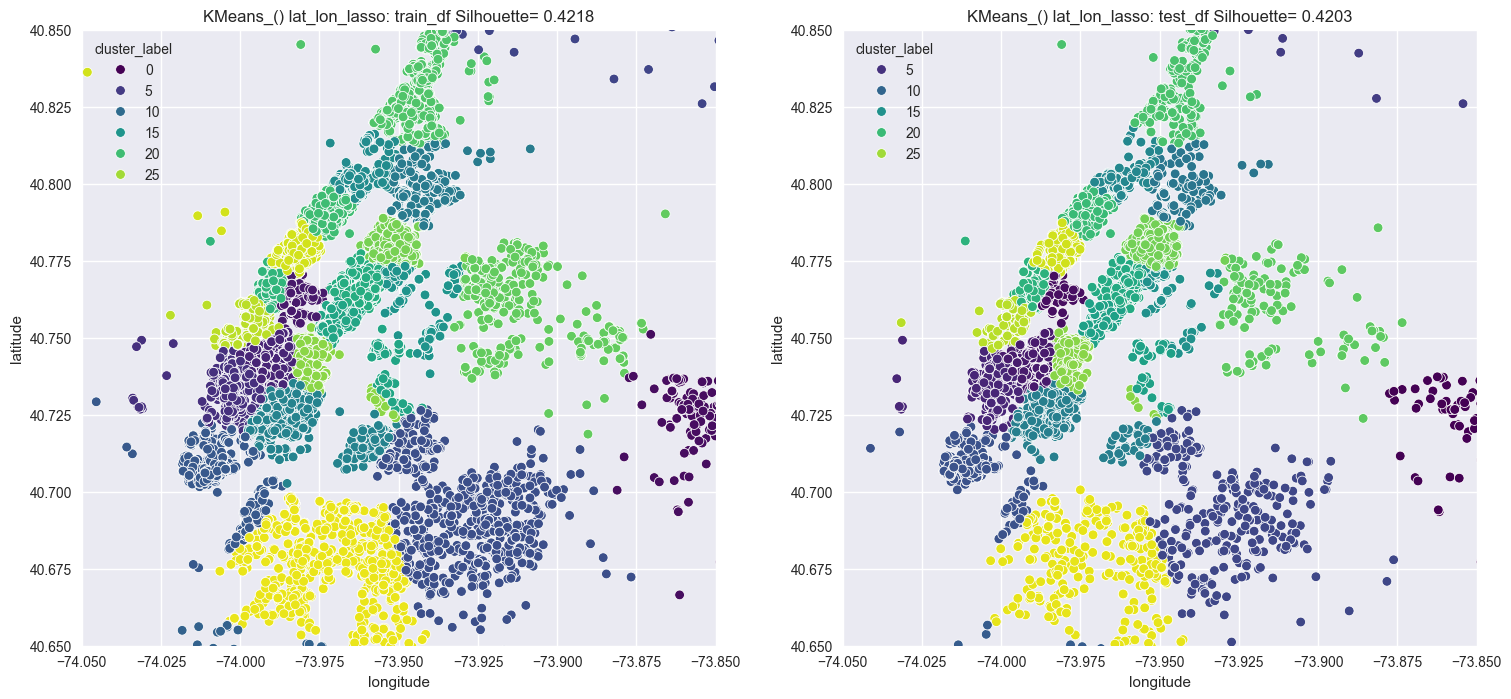

In [113]:
def draw_res(model_name, x: str, y: str, mode: str = "geo", save: str = "yes"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18, 8))
    for num, df in enumerate((train_df, test_df)):
        sns.scatterplot(
            x=df[x], 
            y=df[y], 
            hue=df['cluster_label'], 
            ax=ax[num],
            palette='viridis'
        )
        if mode == "geo":
            ax[num].set(xlim=(-74.05,-73.85))
            ax[num].set(ylim=(40.65,40.85))
        ax[num].set(title=f"{model_name}: {df.name} Silhouette= {metrics[f"Silh_sc_{df.name[:-3]}"][-1]}")

    if save == "yes":
        # save df with cluster label
        models_plots.append(
            {
                'name': model_name,
                'train': train_df.copy(),
                'test': test_df.copy(),
                "train_sil": metrics[f"Silh_sc_train"][-1],
                "test_sil": metrics[f"Silh_sc_test"][-1],
            }
        )


draw_res("KMeans_() lat_lon_lasso", x="longitude", y="latitude", save='no')

##### 3.7 Import K-means from sklearn and compare results.

,KMeans_sk lat_lon_lasso,ftr_imp
0,CatsAllowed,-0.000000
1,Balcony,-0.000000
2,OutdoorSpace,-29.355848
3,Pre-War,-38.085806
4,NewConstruction,-44.052604
5,SwimmingPool,52.749926
6,DogsAllowed,62.127898
7,RoofDeck,-90.085070
8,NoFee,-97.972984
9,HardwoodFloors,-125.660616


'Inertia (or distortion) 4.5779'

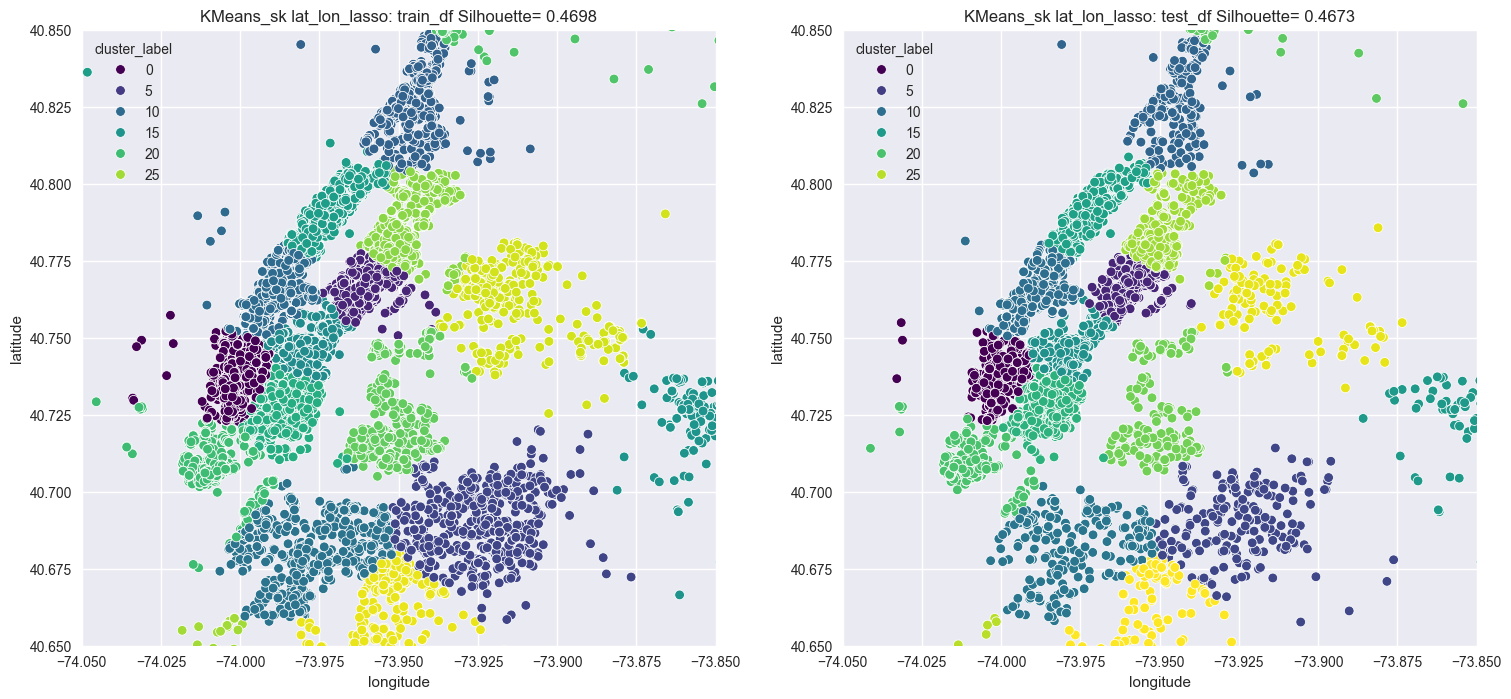

In [114]:
def calc_all(
        model, 
        model_name: str, 
        cluster_ftrs: list,
        eval_ftrs: list,
        base_eval_model, 
        f_imp_res_table: pd.DataFrame, 
        approach: str = "prod",
        save_plot: str = 'yes',
        draw_mode: str = "geo",
        verbose: str = 'yes'
    ):

    cluster_model = fit_cluster_model(
        model=model, cluster_ftrs=cluster_ftrs, approach=approach
    )

    eval_model = calc_metrics(
        name=model_name,
        cluster_ftrs=cluster_ftrs,
        eval_ftrs=eval_ftrs,
        base_eval_model=base_eval_model, 
        results=metrics, 
    )

    f_imp_res_table = calc_feature_importance(
        res_table=f_imp_res_table, 
        eval_ftrs=eval_ftrs,
        model_name=model_name, 
        eval_model=eval_model
    )

    if verbose == 'yes':
        display(f_imp_res_table)
        
        if "means" in model_name.lower():
            display(f"Inertia (or distortion) {round(cluster_model.inertia_, 4)}")

    draw_res(
        model_name=model_name,
        x=cluster_ftrs[0],
        y=cluster_ftrs[1],
        mode=draw_mode,
        save=save_plot
    )
    
    if verbose == "no":
        plt.close()

    return f_imp_res_table


f_imp_res_table = calc_all(
    model=KMeans(n_clusters=30, random_state=42), 
    model_name="KMeans_sk lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
)

#### 4. Implement the next method:

##### 4.1 DBScan algorithm.

In [115]:
@dataclass
class KDNode:
    point_idx: int
    point: np.ndarray
    left: Optional['KDNode'] = None
    right: Optional['KDNode'] = None
    axis: int = 0

In [116]:
@dataclass
class KDTree:
    points: np.ndarray
    root: Optional['KDNode'] = None
    
    def __post_init__(self):
        self.n_samples, self.dim = self.points.shape
        indices = list(range(self.n_samples))
        self.root = self._build(self.points, indices, depth=0)
    
    def _build(
            self, 
            points: np.ndarray, 
            indices: List[int], 
            depth: int
        ) -> Optional[KDNode]:
        # DFS-type algo

        if not indices:
            return None
        
        axis: int = depth % self.dim
        indices.sort(key=lambda idx: points[idx][axis])
        median_idx: int = len(indices) // 2
        
        node = KDNode(
            point_idx=indices[median_idx],
            point=points[indices[median_idx]],
            axis=axis
        )
        
        node.left = self._build(points, indices[:median_idx], depth + 1)
        node.right = self._build(points, indices[median_idx + 1:], depth + 1)
        return node

    def _query_radius(
            self,
            node: Optional[KDNode], 
            target: np.ndarray, 
            target_idx: int, 
            radius: float, 
            neighbors: List[int]
        ) -> None:
        # DFS-type algo

        if node is None:
            return
        
        dist = np.linalg.norm(target - node.point)
        # mark neighbor
        if dist <= radius and node.point_idx != target_idx:
            neighbors.append(node.point_idx)
        
        axis = node.axis
        diff = target[axis] - node.point[axis]
        
        # get split direction
        if diff <= 0:
            first, second = node.left, node.right
        else:
            first, second = node.right, node.left
        
        # check all first branch nodes through recursion
        self._query_radius(first, target, target_idx, radius, neighbors)
        
        # after check of all first check second branch nodes with condition
        if abs(diff) <= radius:
            self._query_radius(second, target, target_idx, radius, neighbors)
    
    def query_radius(self, target_idx: int, radius: float) -> List[int]:
        neighbors: list = []
        self._query_radius(self.root, self.points[target_idx], target_idx, radius, neighbors)
        return neighbors

In [117]:
@dataclass
class DBSCAN_():
    """
    DBSCAN - Density-Based Spatial Clustering of Applications with Noise. 
    Finds core samples of high density and expands clusters from them. 
    This algorithm is particularly good for data which contains clusters 
    of similar density and can find clusters of arbitrary shape.

    Prepocess: Standard or MinMax scaler
    Algo complexity (Fit): O(n_samples * log(n_samples)) with spatial indexing,
                           O(n_samples^2) without indexing
    Algo complexity (Predict): O(n_samples * n_features)
    """
    eps: float = 0.5
    min_samples: int = 5
    algorithm: str = "brute"
    labels_ = None
    core_sample_indices_ = None
    components_ = None
    
    def _brute_force_neighbors(self, X) -> None:
        """O(n_samples^2)"""
        n_samples = X.shape[0]
        neighbors = [[] for _ in range(n_samples)]
        
        for i in range(n_samples):
            for j in range(i + 1, n_samples):
                dist = np.linalg.norm(X[i] - X[j])
                if dist <= self.eps:
                    neighbors[i].append(j)
                    neighbors[j].append(i)
        
        return neighbors
    
    def _kd_tree_neighbors(self, X):
        """O(n log n)"""
        n_samples = X.shape[0]
        kdtree = KDTree(X)
        neighbors = [[] for _ in range(n_samples)]
        
        for i in range(n_samples):
            neighbor_indices = kdtree.query_radius(i, self.eps)
            neighbors[i] = neighbor_indices
        
        return neighbors

    def _compute_neighbors(self, X):
        if self.algorithm == 'brute':
            return self._brute_force_neighbors(X)
        elif self.algorithm == 'kd_tree':
            return self._kd_tree_neighbors(X)
        else:
            raise ValueError(f"Unknown algorithm: {self.algorithm}")
    
    def _expand_cluster(self, X, point_idx, cluster_id):
        # Use deque for BFS
        queue = deque()
        queue.append(point_idx)
        self.labels_[point_idx] = cluster_id
        
        while queue:
            current_point = queue.popleft()
            
            # If current point is core, add its neighbors to queue
            if len(self._neighbors[current_point]) >= self.min_samples:
                for neighbor_idx in self._neighbors[current_point]:
                    if self.labels_[neighbor_idx] == -2:
                        self.labels_[neighbor_idx] = cluster_id
                        queue.append(neighbor_idx)

                    elif self.labels_[neighbor_idx] == -1:
                        self.labels_[neighbor_idx] = cluster_id

    def fit(self, X, y=None):
        # X - 2D array
        X = np.asarray(X)
        n_samples = X.shape[0]
        # labels: -2: unvisited, -1: noise, >=0: cluster
        self.labels_ = np.full(n_samples, -2, dtype=int)
        self._neighbors = self._compute_neighbors(X)
        cluster_id = 0

        for point_idx in range(n_samples):
            if self.labels_[point_idx] != -2:
                continue
                
            # Check if point is core
            if len(self._neighbors[point_idx]) >= self.min_samples:
                self._expand_cluster(X, point_idx, cluster_id)
                cluster_id += 1
            else:
                # mark noise
                self.labels_[point_idx] = -1 

        core_mask = np.array([len(self._neighbors[i]) >= self.min_samples 
                              for i in range(n_samples)])
        self.core_sample_indices_ = np.where(core_mask)[0]
        return self
    
    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

##### 4.2 Fit cluster algorithm with 30 clusters on 'longitude' and 'latitude' features, make prediction for training and test samples.

In [ ]:
_ = calc_all(
    model=DBSCAN_(min_samples=5, eps=0.001, algorithm="brute"), 
    model_name="DBSCAN_(alg=brute)_prod lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
    save_plot='no',
    verbose="n/a"
)

ZeroDivisionError: division by zero

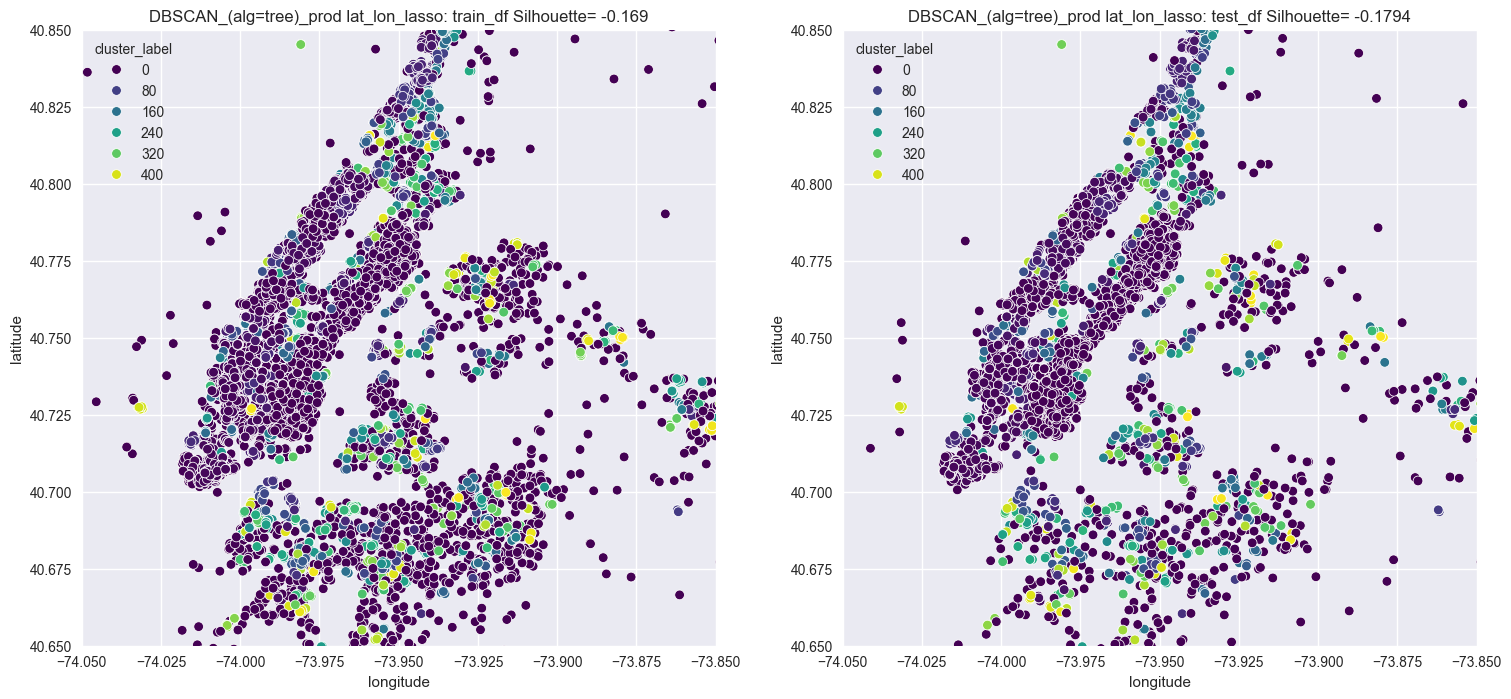

In [ ]:
_ = calc_all(
    model=DBSCAN_(min_samples=5, eps=0.001, algorithm="kd_tree"), 
    model_name="DBSCAN_(alg=tree)_prod lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
    save_plot='no',
    verbose="n/a"
)

,DBSCAN_sk_kaggle lat_lon_lasso,ftr_imp,DBSCAN_sk_prod lat_lon_lasso,ftr_imp,KMeans_sk lat_lon_lasso,ftr_imp
0,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,NewConstruction,-16.499624,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,SwimmingPool,27.962337,SwimmingPool,32.228306,Pre-War,-38.085806
4,OutdoorSpace,-43.952850,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,Pre-War,-48.979875,Pre-War,-57.444664,SwimmingPool,52.749926
6,DogsAllowed,75.400159,DogsAllowed,76.456335,DogsAllowed,62.127898
7,NoFee,-90.497505,NoFee,-86.343272,RoofDeck,-90.085070
8,RoofDeck,-108.732310,RoofDeck,-105.515742,NoFee,-97.972984
9,HardwoodFloors,-125.145172,Dishwasher,120.473126,HardwoodFloors,-125.660616


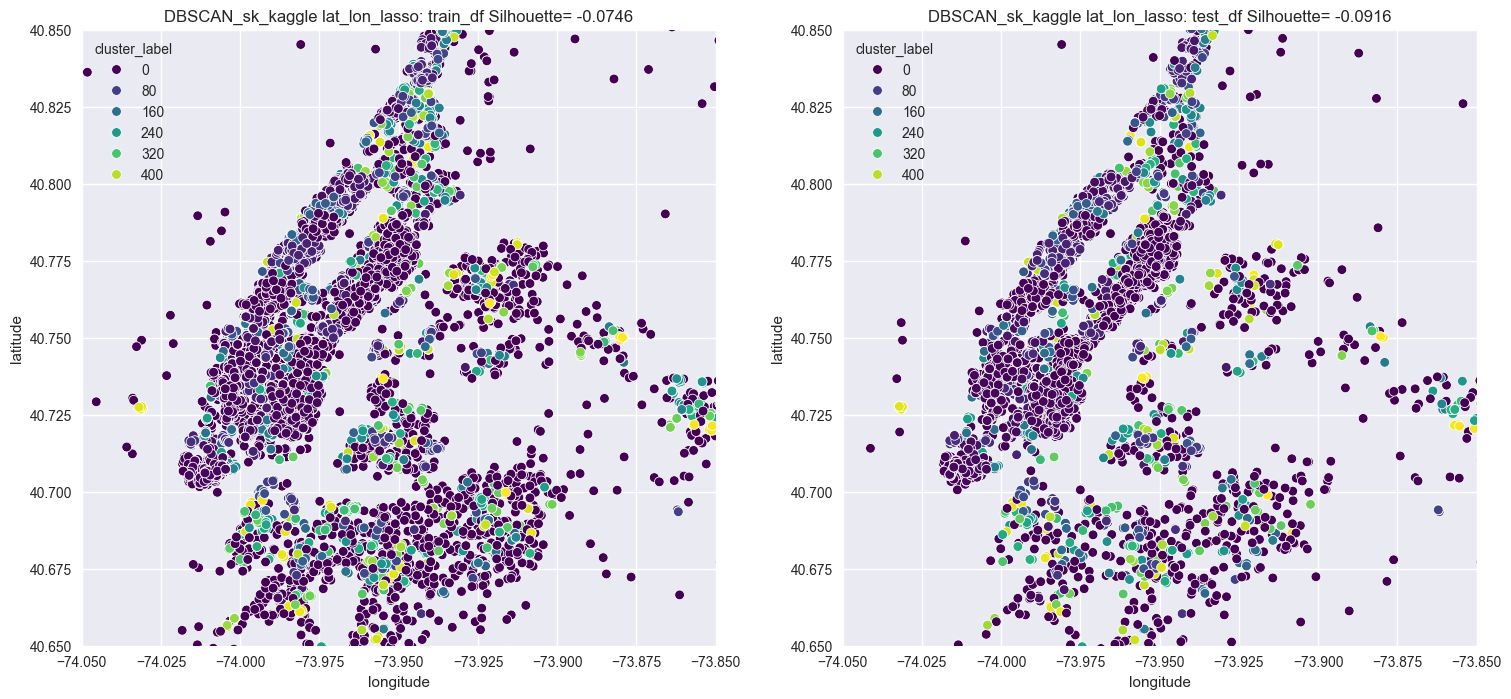

In [ ]:
_ = calc_all(
    model=DBSCAN(min_samples=5, eps=0.001), 
    model_name="DBSCAN_sk_kaggle lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
    approach="kaggle",
    save_plot='no',
    verbose="n/a"
)

In [ ]:
f_imp_res_table = calc_all(
    model=DBSCAN(min_samples=5, eps=0.001), 
    model_name="DBSCAN_sk_prod lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table,
)

KeyError: "None of [Index(['longitude', 'latitude'], dtype='object')] are in the [columns]"

#### 5. Implement the next method:

##### 5.1 AgglomerativeClustering algorithm.

In [ ]:
@dataclass
class AgglomerativeClustering_():
    pass

In [ ]:
# algorithm is not mandatory for you, you can import it from sklearn.
f_imp_res_table = calc_all(
    model=AgglomerativeClustering(n_clusters=30), 
    model_name="AgglomerativeClustering_sk_prod lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table
)

#### 6. Implement the next method:

##### 6.1 Gaussian Mixture algorithm.

In [ ]:
@dataclass
class GaussianMixture_():
    pass

,GaussianMixture_sk lat_lon_lasso,ftr_imp,DBSCAN_sk_prod lat_lon_lasso,ftr_imp,KMeans_sk lat_lon_lasso,ftr_imp
0,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,OutdoorSpace,-30.871301,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,NewConstruction,-36.300753,SwimmingPool,32.228306,Pre-War,-38.085806
4,Pre-War,-41.113164,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,DogsAllowed,61.998524,Pre-War,-57.444664,SwimmingPool,52.749926
6,SwimmingPool,76.836946,DogsAllowed,76.456335,DogsAllowed,62.127898
7,NoFee,-94.469761,NoFee,-86.343272,RoofDeck,-90.085070
8,RoofDeck,-103.608546,RoofDeck,-105.515742,NoFee,-97.972984
9,DiningRoom,125.997149,Dishwasher,120.473126,HardwoodFloors,-125.660616


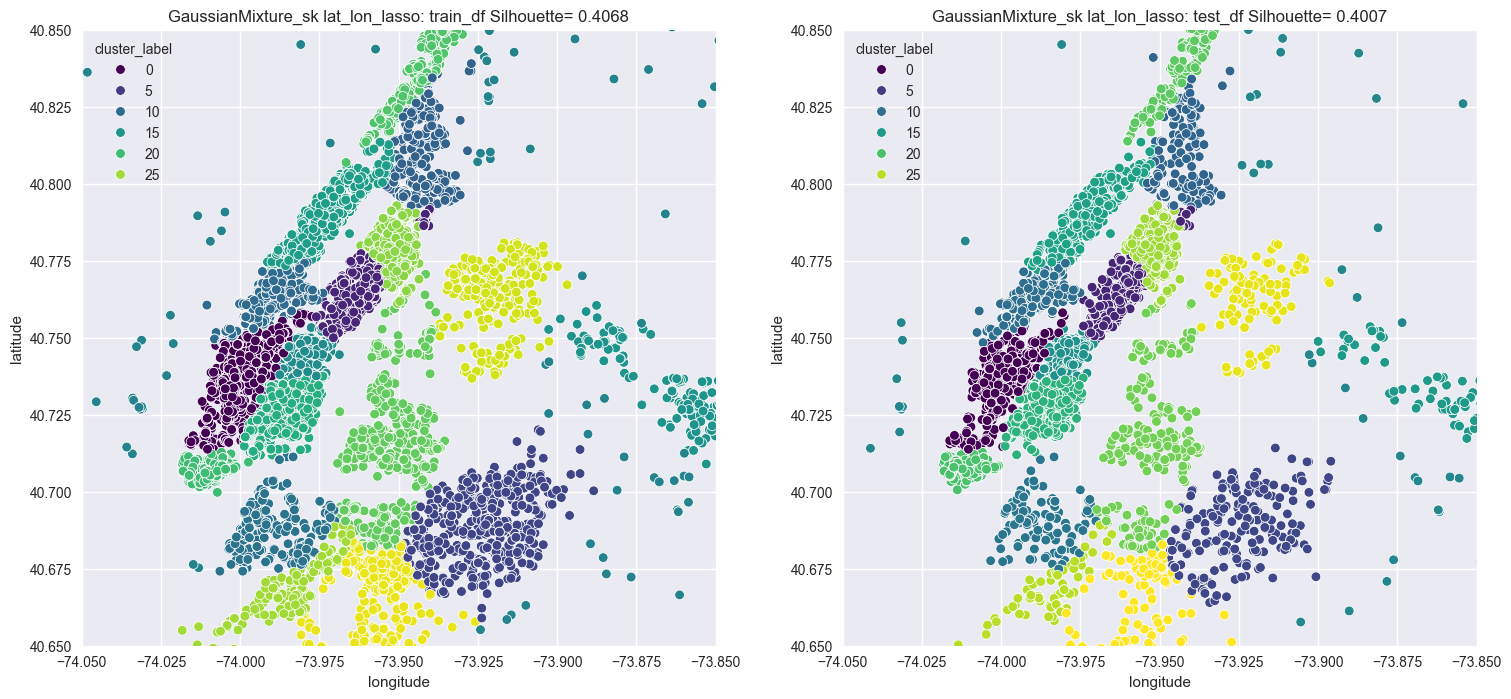

In [ ]:
f_imp_res_table = calc_all(
    model=GaussianMixture(n_components=30, random_state=42), 
    model_name="GaussianMixture_sk lat_lon_lasso", 
    cluster_ftrs=['longitude', 'latitude'],
    eval_ftrs=features + ['cluster_label'],
    base_eval_model=Lasso(random_state=42),
    f_imp_res_table=f_imp_res_table
)

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_() lat_lon_lasso,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,13.0232
1,KMeans_sk lat_lon_lasso,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,1.8995
2,DBSCAN_(alg=tree)_prod lat_lon_lasso,-0.1690,-0.1794,681.9535,670.6089,995.2388,963.9612,0.6134,0.6081,32.5328
3,DBSCAN_sk_prod lat_lon_lasso,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4623
4,DBSCAN_sk_kaggle lat_lon_lasso,-0.0746,-0.0916,684.7196,674.9827,998.3262,967.5796,0.6109,0.6052,0.3457
5,GaussianMixture_sk lat_lon_lasso,0.4068,0.4007,669.9915,656.0407,981.7440,949.0717,0.6238,0.6201,3.4299


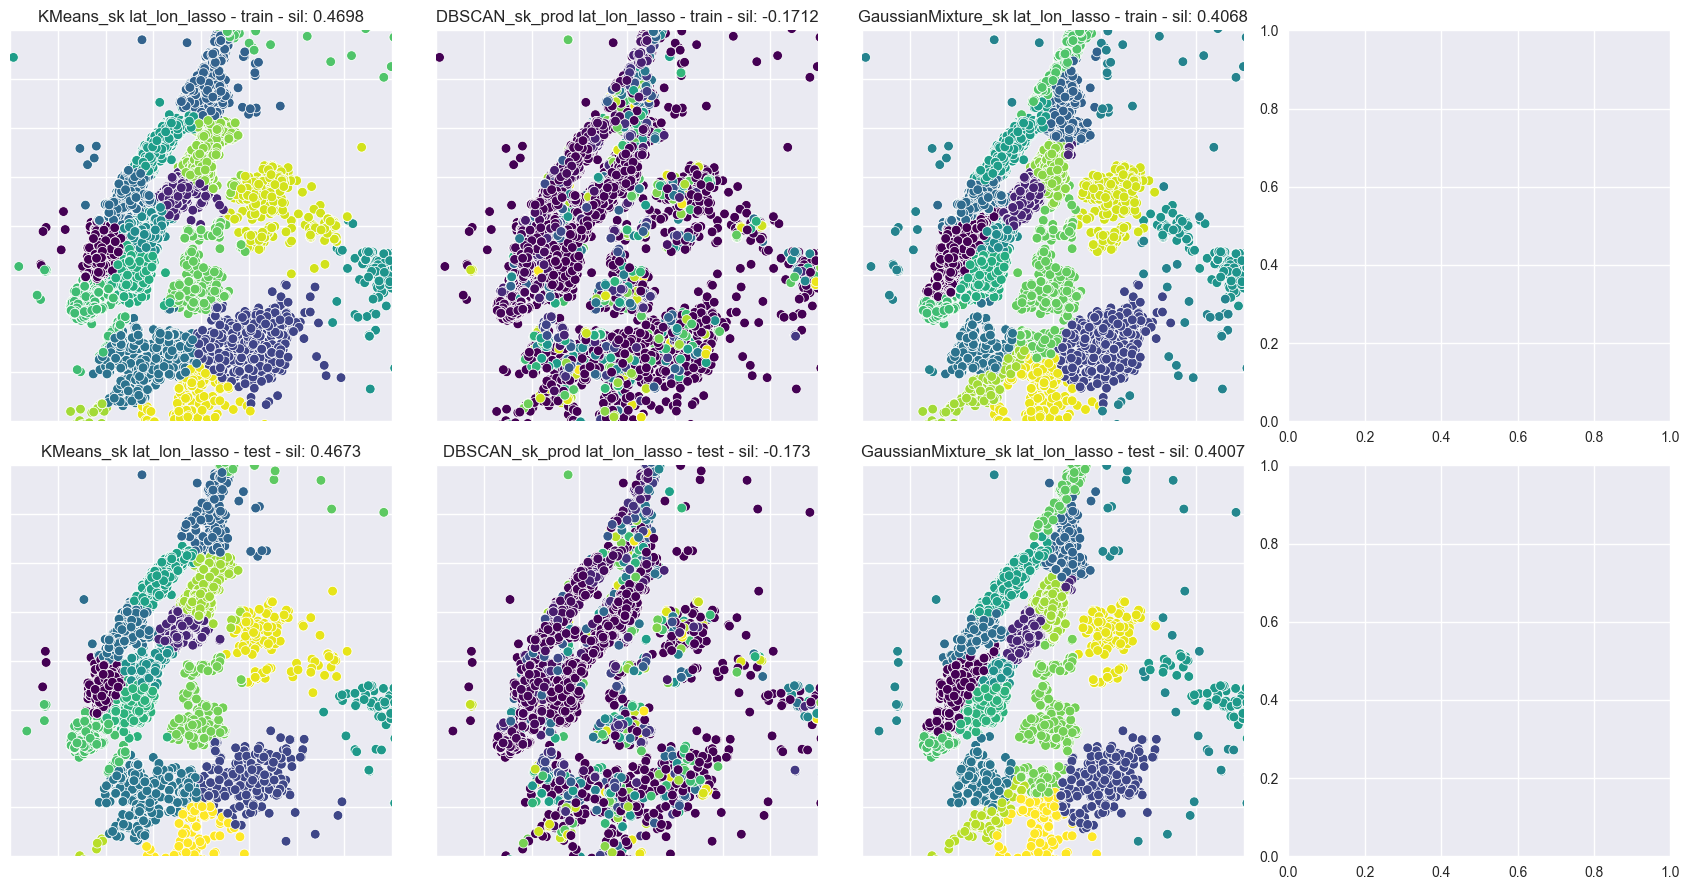

,GaussianMixture_sk lat_lon_lasso,ftr_imp,DBSCAN_sk_prod lat_lon_lasso,ftr_imp,KMeans_sk lat_lon_lasso,ftr_imp
0,CatsAllowed,-0.000000,CatsAllowed,-0.000000,CatsAllowed,-0.000000
1,Balcony,0.000000,Balcony,-0.000000,Balcony,-0.000000
2,OutdoorSpace,-30.871301,NewConstruction,-2.472187,OutdoorSpace,-29.355848
3,NewConstruction,-36.300753,SwimmingPool,32.228306,Pre-War,-38.085806
4,Pre-War,-41.113164,OutdoorSpace,-43.040942,NewConstruction,-44.052604
5,DogsAllowed,61.998524,Pre-War,-57.444664,SwimmingPool,52.749926
6,SwimmingPool,76.836946,DogsAllowed,76.456335,DogsAllowed,62.127898
7,NoFee,-94.469761,NoFee,-86.343272,RoofDeck,-90.085070
8,RoofDeck,-103.608546,RoofDeck,-105.515742,NoFee,-97.972984
9,DiningRoom,125.997149,Dishwasher,120.473126,HardwoodFloors,-125.660616


In [ ]:
def draw_models(x: str, y: str, mode: str = "geo"):
    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(17, 9))
    
    for j, model_data in enumerate(models_plots):
        for i, (df_name, df) in enumerate([('train', model_data['train']), 
                                           ('test', model_data['test'])]):
            sns.scatterplot(
                x=df[x], 
                y=df[y], 
                hue=df['cluster_label'], 
                ax=axes[i, j],
                palette='viridis',
                legend=False
            )
            if mode == "geo":
                axes[i, j].set(xlim=(-74.05, -73.85))
                axes[i, j].set(ylim=(40.65, 40.85))
            axes[i, j].set_title(f"{model_data['name']} - {df_name} - sil: {model_data[f"{df_name}_sil"]}")
            axes[i, j].set_xlabel('')
            axes[i, j].set_ylabel('')
            axes[i, j].set_xticklabels([])
            axes[i, j].set_yticklabels([])
    
    plt.tight_layout()
    plt.show()


display(pd.DataFrame(metrics))
draw_models(x="longitude", y="latitude")
display(f_imp_res_table)

metrics_lat_lon_lasso = metrics.copy()
f_imp_res_table_lat_lon_lasso = f_imp_res_table.copy()
models_plots_lat_lon_lasso = models_plots.copy()

#### 7. Try all these algorithms with different sets of features that might be more efficient in clustering.<br> In the checklist will cluster for 3 features — bedrooms, bathrooms and interest_level.

In [ ]:
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}

f_imp_res_table: pd.DataFrame = pd.DataFrame()
models_plots: list = []

# 1st approach: create new 2 features with information of base features
# (bedrooms, bathrooms, interest_level) in order to simplify visualization
pca = PCA(n_components=2, random_state=42)
train_df[["mix_ftr1", "mix_ftr2"]] = pca.fit_transform(X=train_df[base_features_list])
test_df[["mix_ftr1", "mix_ftr2"]] = pca.transform(X=test_df[base_features_list])

for cluster_method in (
    KMeans(n_clusters=30, random_state=42), 
    DBSCAN(min_samples=5, eps=0.001), 
    AgglomerativeClustering(n_clusters=30),
    GaussianMixture(n_components=30, random_state=42)
    ):
    
    f_imp_res_table = calc_all(
        model=cluster_method, 
        model_name=f"{cluster_method.__class__.__name__}_sk base_ftrs_lasso", 
        cluster_ftrs=["mix_ftr1", "mix_ftr2"],
        # 2nd approach: use bedrooms, bathrooms, interest_level as cluster_ftrs
        # cluster_ftrs=base_features_list,
        eval_ftrs=features + ['cluster_label'],
        base_eval_model=Lasso(random_state=42),
        f_imp_res_table=f_imp_res_table,
        verbose="no"
)

#### 8. Compare the results with the complexity, speed and accuracy of these methods.

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk base_ftrs_lasso,0.9643,0.9615,690.8548,680.8915,1002.3853,970.6475,0.6078,0.6027,0.0657
1,DBSCAN_sk base_ftrs_lasso,0.9983,0.9976,689.6770,678.3455,1001.9325,967.7419,0.6081,0.6051,2.2423
2,GaussianMixture_sk base_ftrs_lasso,0.9596,0.9562,690.0047,679.7417,1000.8008,967.7338,0.6090,0.6051,2.3032


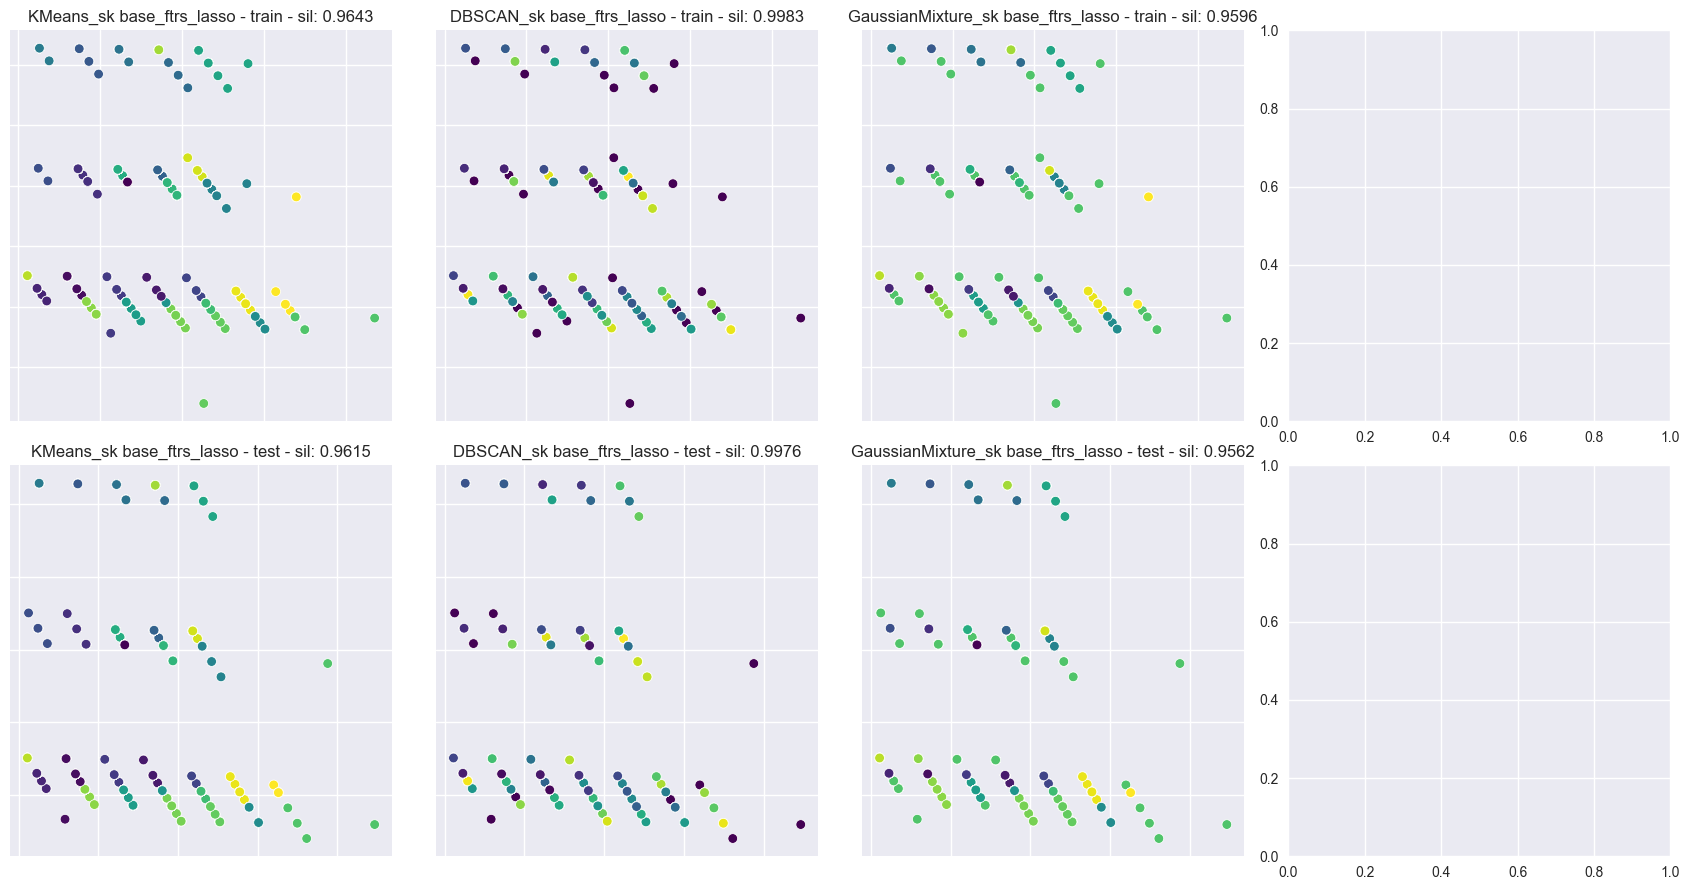

,GaussianMixture_sk base_ftrs_lasso,ftr_imp,DBSCAN_sk base_ftrs_lasso,ftr_imp,KMeans_sk base_ftrs_lasso,ftr_imp
0,Balcony,-0.000000,Balcony,-0.000000,Balcony,-0.000000
1,CatsAllowed,-2.107532,CatsAllowed,-1.533951,CatsAllowed,-1.558213
2,SwimmingPool,34.019454,SwimmingPool,29.663893,SwimmingPool,32.785815
3,Pre-War,-40.442112,NewConstruction,-42.667236,OutdoorSpace,-41.322542
4,OutdoorSpace,-40.767249,OutdoorSpace,-43.519075,Pre-War,-44.358901
5,NewConstruction,-44.465129,Pre-War,-47.195193,NewConstruction,-46.413359
6,DogsAllowed,76.899627,DogsAllowed,75.048126,DogsAllowed,73.837344
7,NoFee,-94.243566,NoFee,-95.409303,NoFee,-95.350026
8,HardwoodFloors,-101.829554,RoofDeck,-100.896304,HardwoodFloors,-104.352676
9,RoofDeck,-105.694240,HardwoodFloors,-106.266821,RoofDeck,-105.486249


In [ ]:
display(pd.DataFrame(metrics))
# 1st approach
draw_models(x="mix_ftr1", y="mix_ftr2", mode="mixed")
# 2nd approach
# draw_models(x="bathrooms", y="bedrooms", mode="mixed")

metrics_base_lasso = metrics.copy()
f_imp_res_table_base_lasso = f_imp_res_table.copy()
models_plots_base_lasso = models_plots.copy()

#### Bonus:

##### B1. For additional task, you can try different models instead of Lasso.

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk lat_lon_ridge,0.4698,0.4673,679.9964,667.9924,991.7926,959.6232,0.6160,0.6117,0.0637
1,DBSCAN_sk lat_lon_ridge,-0.1712,-0.1730,681.3528,668.8847,993.4763,962.1407,0.6147,0.6096,0.4427
2,GaussianMixture_sk lat_lon_ridge,0.4068,0.4007,670.7391,656.5011,981.4287,949.0559,0.6240,0.6202,3.6566


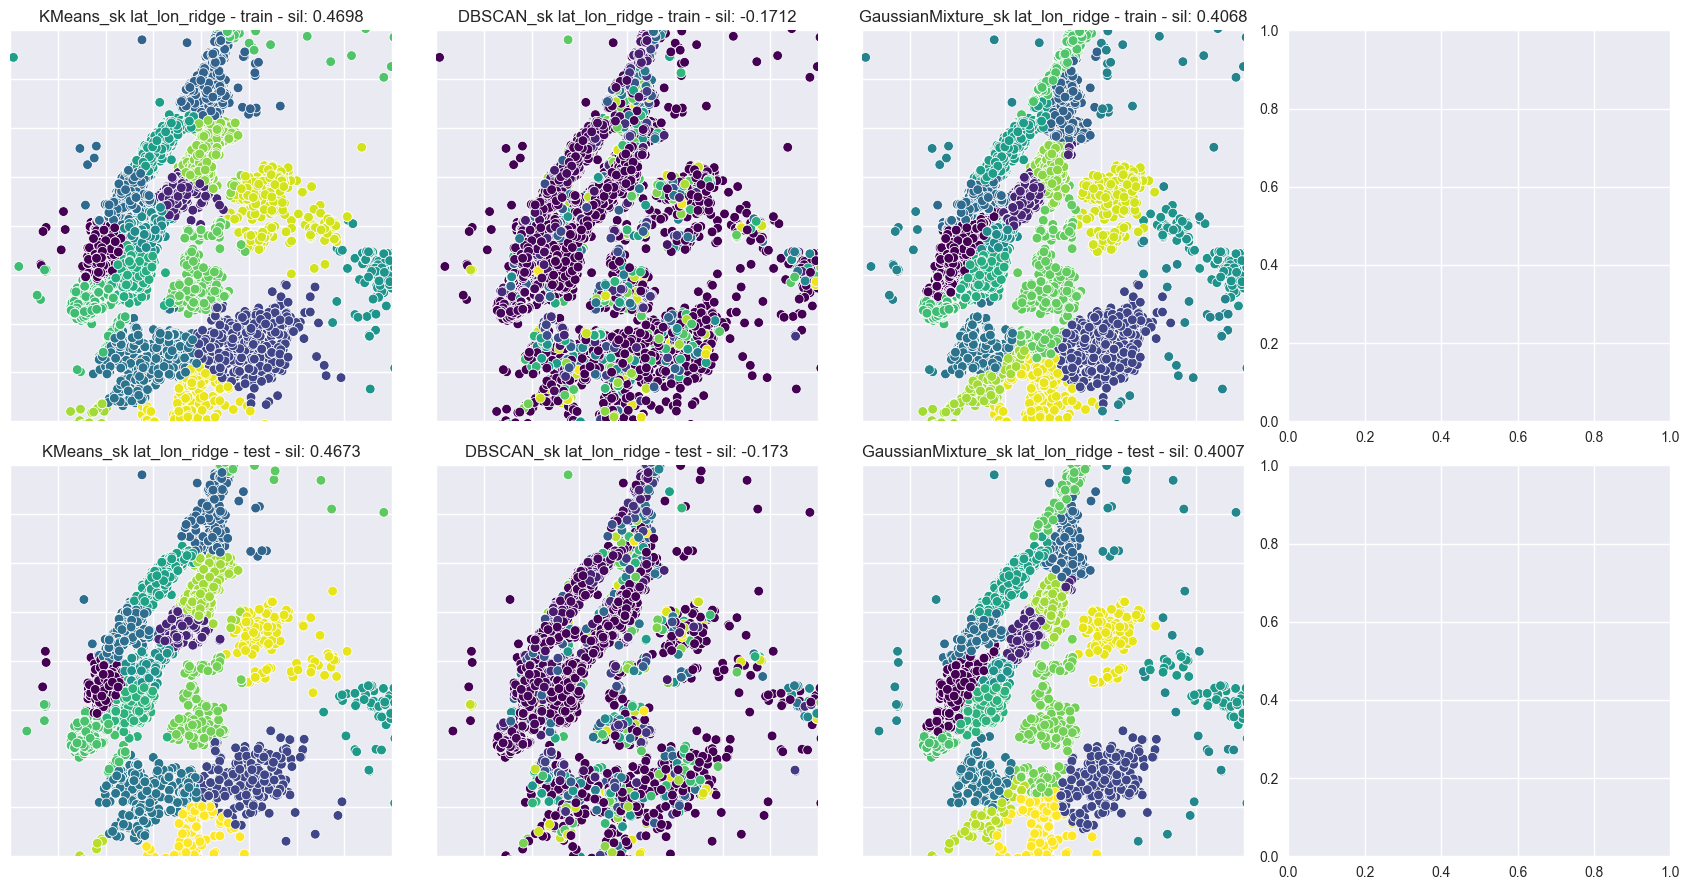

,GaussianMixture_sk lat_lon_ridge,ftr_imp,DBSCAN_sk lat_lon_ridge,ftr_imp,KMeans_sk lat_lon_ridge,ftr_imp
0,Balcony,-4.909353,Balcony,-14.760459,Balcony,-15.141554
1,CatsAllowed,-38.169368,NewConstruction,-24.581781,Pre-War,-44.096133
2,Pre-War,-47.064623,SwimmingPool,52.450833,OutdoorSpace,-44.467955
3,OutdoorSpace,-47.659343,CatsAllowed,-54.245235,CatsAllowed,-58.185116
4,NewConstruction,-59.431651,OutdoorSpace,-58.537902,NewConstruction,-67.811968
5,SwimmingPool,97.157060,Pre-War,-63.988190,SwimmingPool,73.359329
6,NoFee,-100.671834,NoFee,-92.629516,RoofDeck,-99.544269
7,DogsAllowed,101.283266,RoofDeck,-115.345743,NoFee,-104.676941
8,RoofDeck,-113.145038,Dishwasher,127.322842,DogsAllowed,120.286825
9,DiningRoom,130.529875,DogsAllowed,131.346910,HardwoodFloors,-133.219226


In [ ]:
# Ridge
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}

f_imp_res_table: pd.DataFrame = pd.DataFrame()
models_plots: list = []

for cluster_method in (
    KMeans(n_clusters=30, random_state=42), 
    DBSCAN(min_samples=5, eps=0.001), 
    AgglomerativeClustering(n_clusters=30),
    GaussianMixture(n_components=30, random_state=42)
    ):
    
    f_imp_res_table = calc_all(
        model=cluster_method, 
        model_name=f"{cluster_method.__class__.__name__}_sk lat_lon_ridge", 
        cluster_ftrs=['longitude', 'latitude'],
        eval_ftrs=features + ['cluster_label'],
        base_eval_model=Ridge(random_state=42),
        f_imp_res_table=f_imp_res_table,
        verbose="no"
)

display(pd.DataFrame(metrics))
draw_models(x="longitude", y="latitude")

metrics_lat_lon_ridge = metrics.copy()
f_imp_res_table_lat_lon_ridge = f_imp_res_table.copy()
models_plots__lat_lon_ridge = models_plots.copy()

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk lat_lon_el_net,0.4698,0.4673,1048.9742,1026.1044,1481.6135,1426.0153,0.1431,0.1424,0.0873
1,DBSCAN_sk lat_lon_el_net,-0.1712,-0.1730,1049.7009,1026.7003,1482.4228,1426.5037,0.1422,0.1419,0.4926
2,GaussianMixture_sk lat_lon_el_net,0.4068,0.4007,1046.5495,1023.8530,1479.0713,1423.6015,0.1460,0.1453,3.6152


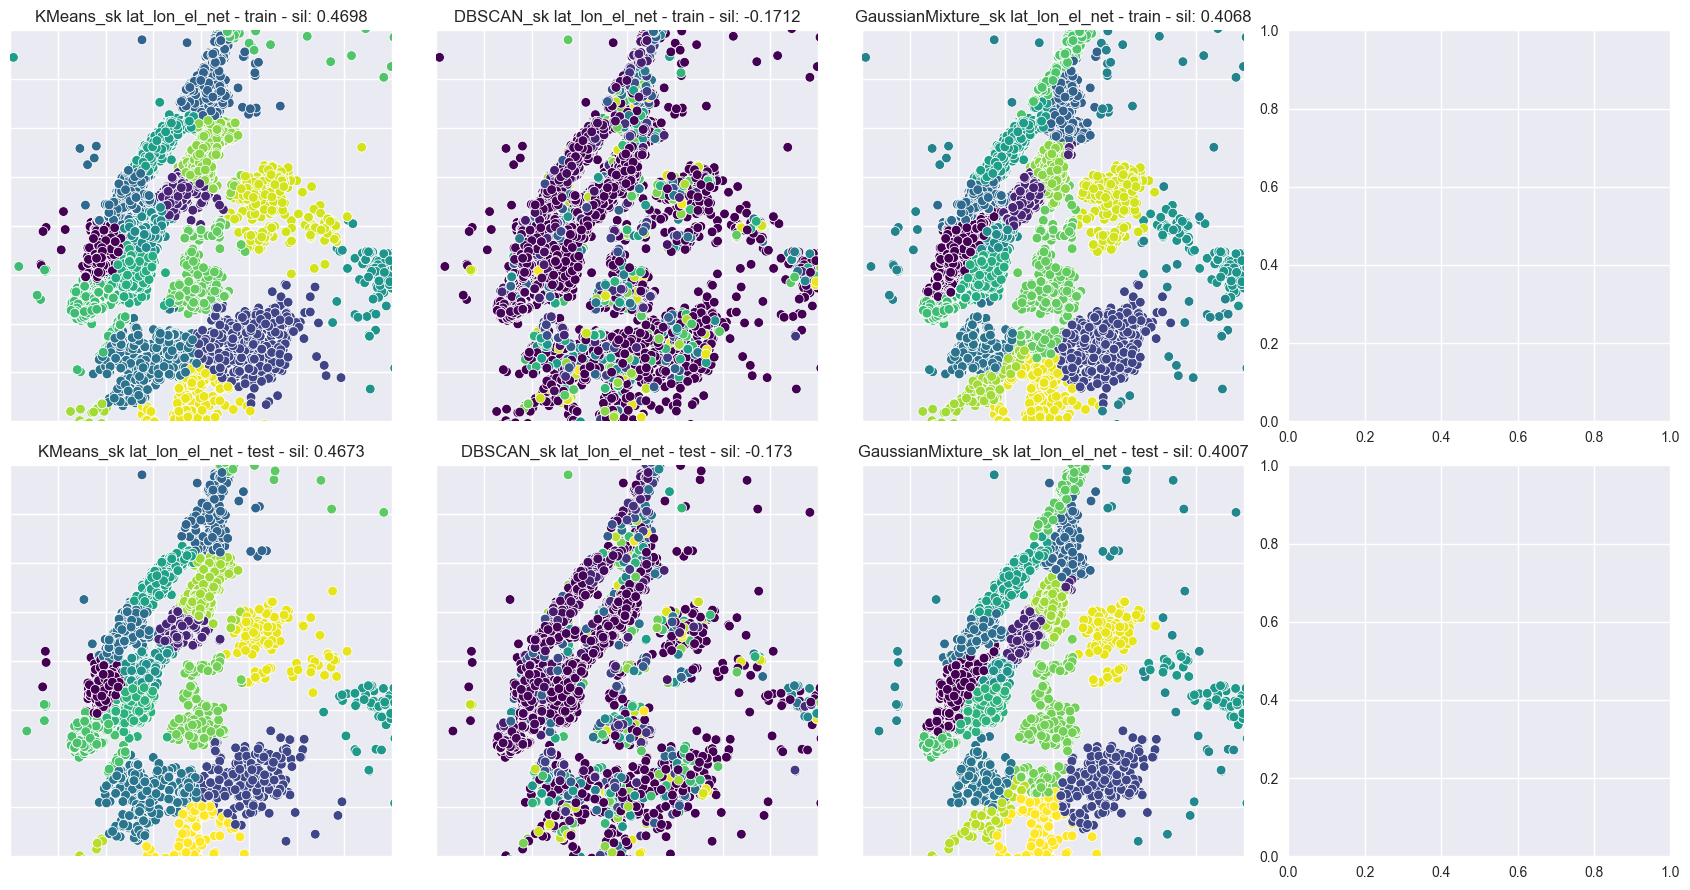

,GaussianMixture_sk lat_lon_el_net,ftr_imp,DBSCAN_sk lat_lon_el_net,ftr_imp,KMeans_sk lat_lon_el_net,ftr_imp
0,NewConstruction,0.000000,NewConstruction,0.076944,NewConstruction,0.000000
1,HighSpeedInternet,3.350259,HighSpeedInternet,3.479352,HighSpeedInternet,3.466919
2,HardwoodFloors,8.281736,HardwoodFloors,8.827712,HardwoodFloors,8.898808
3,LaundryInBuilding,-16.166761,LaundryInBuilding,-16.627099,LaundryInBuilding,-16.367213
4,RoofDeck,21.163103,RoofDeck,21.287002,RoofDeck,21.572207
5,Pre-War,-21.928042,Pre-War,-22.242247,Pre-War,-21.922543
6,LaundryinBuilding,28.653195,LaundryinBuilding,28.879568,LaundryinBuilding,29.055296
7,CatsAllowed,37.691947,CatsAllowed,37.805910,CatsAllowed,37.619258
8,SwimmingPool,40.070978,SwimmingPool,39.633929,SwimmingPool,39.877024
9,DogsAllowed,46.207908,DogsAllowed,46.573373,DogsAllowed,46.327761


In [ ]:
# ElasticNet
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}

f_imp_res_table: pd.DataFrame = pd.DataFrame()
models_plots: list = []

for cluster_method in (
    KMeans(n_clusters=30, random_state=42), 
    DBSCAN(min_samples=5, eps=0.001), 
    AgglomerativeClustering(n_clusters=30),
    GaussianMixture(n_components=30, random_state=42)
    ):
    
    f_imp_res_table = calc_all(
        model=cluster_method, 
        model_name=f"{cluster_method.__class__.__name__}_sk lat_lon_el_net", 
        cluster_ftrs=['longitude', 'latitude'],
        eval_ftrs=features + ['cluster_label'],
        base_eval_model=ElasticNet(random_state=42),
        f_imp_res_table=f_imp_res_table,
        verbose="no"
)

display(pd.DataFrame(metrics))
draw_models(x="longitude", y="latitude")

metrics_lat_lon_el_net = metrics.copy()
f_imp_res_table_lat_lon_el_net = f_imp_res_table.copy()
models_plots_lat_lon_el_net = models_plots.copy()

In [ ]:
display(pd.DataFrame(metrics_lat_lon_lasso))
display(pd.DataFrame(metrics_lat_lon_ridge))
display(pd.DataFrame(metrics_lat_lon_el_net))

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_() lat_lon_lasso,0.4218,0.4203,684.0225,672.1858,999.9457,966.4209,0.6097,0.6061,13.0232
1,KMeans_sk lat_lon_lasso,0.4698,0.4673,679.3550,667.6030,992.1395,959.6436,0.6158,0.6116,1.8995
2,DBSCAN_(alg=tree)_prod lat_lon_lasso,-0.1690,-0.1794,681.9535,670.6089,995.2388,963.9612,0.6134,0.6081,32.5328
3,DBSCAN_sk_prod lat_lon_lasso,-0.1712,-0.1730,680.7352,668.2748,993.8240,962.0382,0.6144,0.6097,0.4623
4,DBSCAN_sk_kaggle lat_lon_lasso,-0.0746,-0.0916,684.7196,674.9827,998.3262,967.5796,0.6109,0.6052,0.3457
5,GaussianMixture_sk lat_lon_lasso,0.4068,0.4007,669.9915,656.0407,981.7440,949.0717,0.6238,0.6201,3.4299


,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk lat_lon_ridge,0.4698,0.4673,679.9964,667.9924,991.7926,959.6232,0.6160,0.6117,0.0637
1,DBSCAN_sk lat_lon_ridge,-0.1712,-0.1730,681.3528,668.8847,993.4763,962.1407,0.6147,0.6096,0.4427
2,GaussianMixture_sk lat_lon_ridge,0.4068,0.4007,670.7391,656.5011,981.4287,949.0559,0.6240,0.6202,3.6566


,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk lat_lon_el_net,0.4698,0.4673,1048.9742,1026.1044,1481.6135,1426.0153,0.1431,0.1424,0.0873
1,DBSCAN_sk lat_lon_el_net,-0.1712,-0.1730,1049.7009,1026.7003,1482.4228,1426.5037,0.1422,0.1419,0.4926
2,GaussianMixture_sk lat_lon_el_net,0.4068,0.4007,1046.5495,1023.8530,1479.0713,1423.6015,0.1460,0.1453,3.6152


##### B2. You could apply optimization methods to hyperparameters of algorithms, e.g. to find the optimal number of clusters.

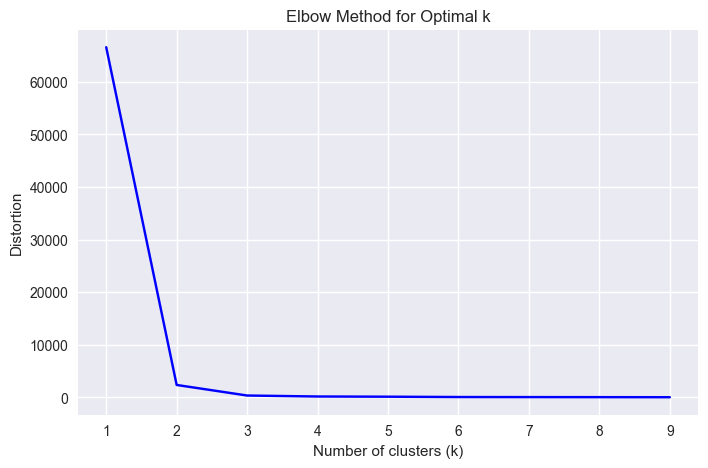

In [ ]:
def elbow_method(X: pd.DataFrame):

    K_range, distortions = range(1, 10), []
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
        distortions.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(K_range, distortions, 'bx-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Distortion')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()

elbow_method(X=train_df[['longitude', 'latitude']])

In [ ]:
def elbow_method_sil(X: pd.DataFrame):

    K_range, sil_sc = range(2, 10), []
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        cluster = kmeans.fit_predict(X)
        sil_sc.append(silhouette_score(X, cluster))

    plt.figure(figsize=(8, 5))
    plt.plot(K_range, sil_sc, 'bx-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Sil_sc')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()

elbow_method_sil(X=train_df[['longitude', 'latitude']])

##### B3. You could combine cluster features from different algorithms and apply feature selection from previous chapters.

,ftr_name,importance_mean
0,bathrooms,0.351 +/- 0.003
1,bedrooms,0.246 +/- 0.002
2,cluster_label,0.056 +/- 0.001
3,interest_level,0.044 +/- 0.001
4,Doorman,0.043 +/- 0.001
5,LaundryinUnit,0.019 +/- 0.001
6,Elevator,0.007 +/- 0.000
7,FitnessCenter,0.006 +/- 0.000
8,LaundryinBuilding,0.006 +/- 0.000
9,HardwoodFloors,0.005 +/- 0.000


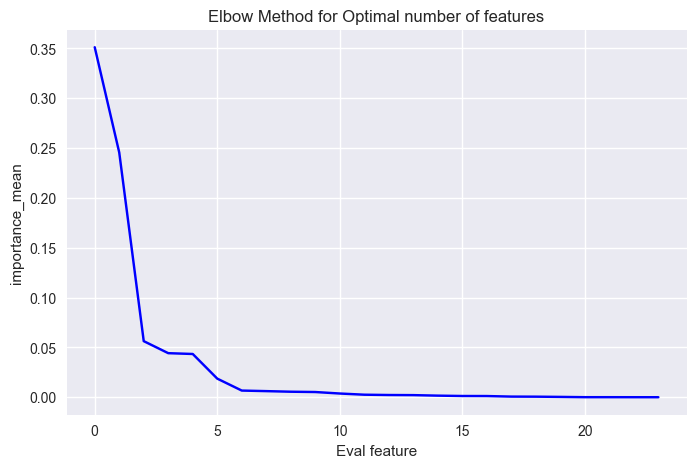

In [ ]:
OPTIMAL_CLSTR_N = 5
metrics: dict = {
    'model': [], 
    'Silh_sc_train': [],
    'Silh_sc_test': [],
    "MAE_train": [],
    "MAE_test": [],
    "RMSE_train": [],
    "RMSE_test": [],
    "R2_train": [],
    "R2_test": [],
    "fit/predict_time": []
}
f_imp_res_table: pd.DataFrame = pd.DataFrame()
models_plots: list = []

cluster_ftrs = ['longitude', 'latitude']
eval_ftrs = features + ['cluster_label']
model = fit_cluster_model(
    model=GaussianMixture(n_components=OPTIMAL_CLSTR_N, random_state=42),
    cluster_ftrs=cluster_ftrs
)

X_train: pd.DataFrame = train_df[eval_ftrs]
y_train: pd.DataFrame = train_df["price"]

X_test: pd.DataFrame = test_df[eval_ftrs]
y_test: pd.DataFrame = test_df["price"]

sc = MinMaxScaler()
X_train_norm = pd.DataFrame(sc.fit_transform(X=X_train))
X_test_norm = pd.DataFrame(sc.transform(X=X_test))


perm = permutation_importance(
    Ridge(random_state=42).fit(X_train_norm, y_train), 
    X_train_norm, 
    y_train,
    scoring="r2",
    n_repeats=30,
    random_state=42
)

out_perm: dict = {"ftr_name": [], "importance_mean": []}

for i in perm.importances_mean.argsort()[::-1]:
    if perm.importances_mean[i] - 2 * perm.importances_std[i] > 0:
        out_perm["ftr_name"].append(eval_ftrs[i])
        out_perm["importance_mean"].append(
            f"{perm.importances_mean[i]:.3f} +/- {perm.importances_std[i]:.3f}"
        )

display(pd.DataFrame(out_perm))

# plot elbow for perm importances
plt.figure(figsize=(8, 5))
plt.plot(
    range(len(perm.importances_mean)), 
    [perm.importances_mean[x] for x in perm.importances_mean.argsort()[::-1]], 
    'bx-')
plt.xlabel('Eval feature')
plt.ylabel('importance_mean')
plt.title('Elbow Method for Optimal number of features')
plt.grid(True)
plt.show()

,model,Silh_sc_train,Silh_sc_test,MAE_train,MAE_test,RMSE_train,RMSE_test,R2_train,R2_test,fit/predict_time
0,KMeans_sk lat_lon_ridge,0.4698,0.4673,679.9964,667.9924,991.7926,959.6232,0.6160,0.6117,0.0637
1,DBSCAN_sk lat_lon_ridge,-0.1712,-0.1730,681.3528,668.8847,993.4763,962.1407,0.6147,0.6096,0.4427
2,GaussianMixture_sk lat_lon_ridge,0.4068,0.4007,670.7391,656.5011,981.4287,949.0559,0.6240,0.6202,3.6566
0,GaussianMixture_sk lat_lon_ridge_top10_perm,0.5485,0.5795,663.7173,649.3632,971.8704,936.4863,0.6313,0.6302,0.3764


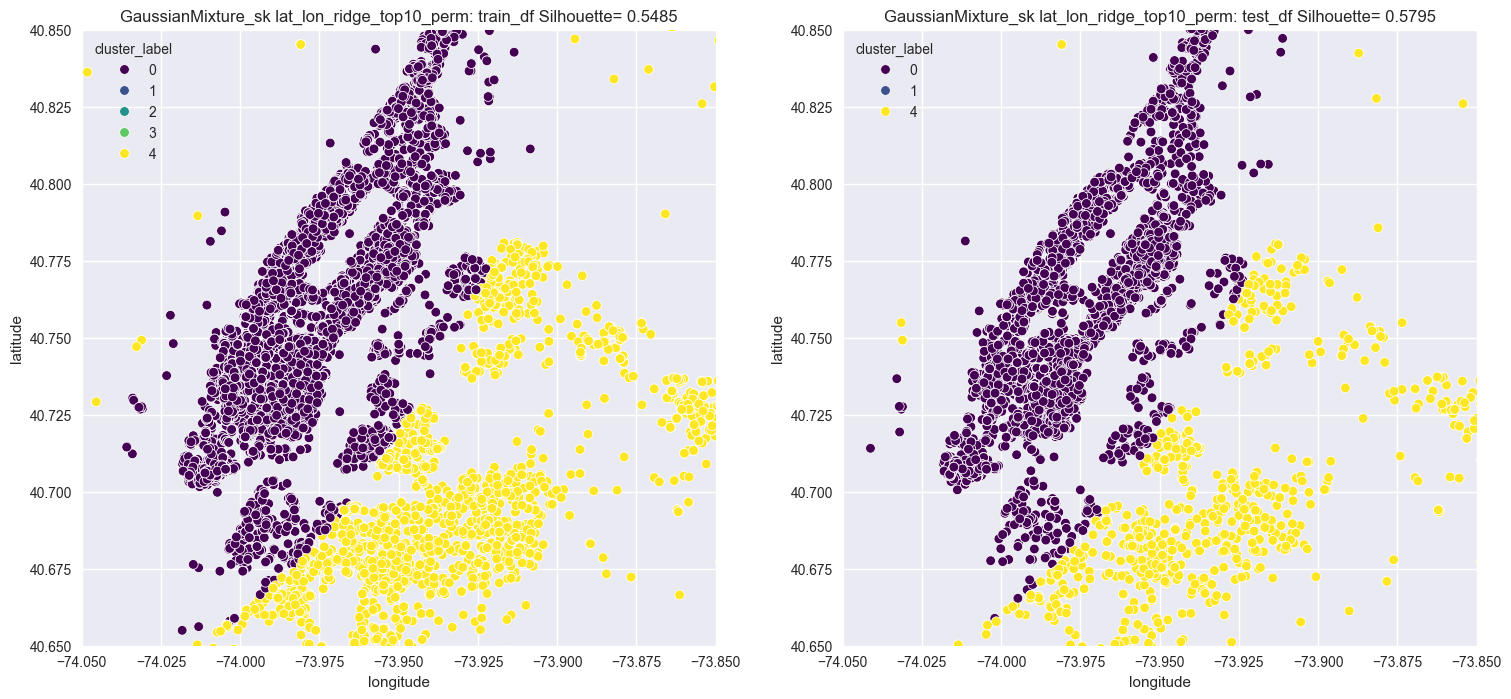

In [ ]:
OPTIMAL_FTR_NUM = 6

new_eval_ftrs = [
    eval_ftrs[x] for x in perm.importances_mean.argsort()[:OPTIMAL_FTR_NUM:-1]
]

_ = calc_metrics(
    name="GaussianMixture_sk lat_lon_ridge_top6_ftrs_5_clstr",
    cluster_ftrs=cluster_ftrs,
    eval_ftrs=new_eval_ftrs,
    base_eval_model=Ridge(random_state=42), 
    results=metrics, 
)

display(pd.concat([pd.DataFrame(metrics_lat_lon_ridge), pd.DataFrame(metrics)]))

draw_res(
    model_name="GaussianMixture_sk lat_lon_ridge_top6_ftrs_5_clstr",
    x=cluster_ftrs[0],
    y=cluster_ftrs[1],
    save="no"
)

#### * Sources
- Part 3.3 Silhouette coefficient [Hidden Markov models for malware classification](https://www.researchgate.net/publication/272017073_Hidden_Markov_models_for_malware_classification)

In [ ]:
total_seconds = time.time() - notebook_time
print(f"{int(total_seconds // 60)}m {round(total_seconds % 60, 1)}s")

168m 28.3s
